# Per-quantile one-sided CQR — constants + empirical validity

The exceedance-probability product claims ("90% chance this day settles in the
top 10% of the archive") need **each quantile head individually calibrated
one-sided** — the shipped symmetric band constant only guarantees the *joint*
90% band, and can park all of its miscoverage on one tail. This notebook
computes the six per-level shifts for **M3_base** (`qn8727_s0`, cache only —
nothing retrains) across **all four variables**, and measures how honest each
calibrated tail actually is on days the calibration never saw.

Setup choices, mirroring `make_debias_tables.py`:

- Data pipeline = `train_quantile_debias` (`preflight → load_and_verify →
  add_features → split → shrink`), **no archive refresh** — evaluate exactly
  what the fits saw.
- The trainer's `test` blocks are halved by **day parity**: odd days fit the
  shifts (calibration), even days measure validity (evaluation). Every test
  month lands in both halves and no day is shared, so the validity numbers are
  out-of-sample for both the fits *and* the shifts.
- Gated cells are **not** excluded — the shipped symmetric Q was computed
  across all cells too (`compute_cqr` runs before gating). A gate-filtered
  variant is a possible refinement.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

import train_quantile_debias as tqd

MODEL_TAG = "qn8727_s0"   # the shipped full-grid fits — loaded from cache, never retrained
CELL_LIMIT = None         # None = all 8727 cells; a small number = smoke run (constants not saved)

QUANTILE_LEVELS = tqd.QUANTILES                 # [.01, .05, .10, .50, .90, .95, .99]
SIDED_LEVELS = [q for q in QUANTILE_LEVELS if q != 0.50]
LEVEL_COLUMN = {level: i for i, level in enumerate(QUANTILE_LEVELS)}

# the source pipeline takes ~20 min; cache the shrunk frame (feather keeps the
# float32/category dtypes). Delete the file to rebuild after any data change
# (new hres pulls, cells.csv edits, archive refresh).
FRAME_CACHE = tqd.HERE / "data" / "pipeline_frame_full.feather"
if CELL_LIMIT is None and FRAME_CACHE.exists():
    data = pd.read_feather(FRAME_CACHE)
    tqd.log(f"loaded cached pipeline frame {FRAME_CACHE.name}: {len(data):,} rows"
            " (delete the file to rebuild from source)")
else:
    static_cells = tqd.preflight(CELL_LIMIT, allow_partial=False)
    data = tqd.load_and_verify(static_cells, allow_partial=False)
    data = tqd.add_features(data)
    data = tqd.split(data)
    data = tqd.shrink(data).reset_index(drop=True)   # feather needs a default index
    if CELL_LIMIT is None:
        data.to_feather(FRAME_CACHE)
        tqd.log(f"cached pipeline frame -> {FRAME_CACHE}")

test_rows = data[data.role == "test"]
calibration_rows = test_rows[test_rows.date.dt.day % 2 == 1]  # odd days fit the shifts
evaluation_rows = test_rows[test_rows.date.dt.day % 2 == 0]   # even days measure honesty
print(f"test rows: {len(test_rows):,} -> calibration {len(calibration_rows):,}"
      f" / evaluation {len(evaluation_rows):,}")


[21:24:43] cells.csv: 8727 cells


[21:24:43] preflight OK: 8727 cells, elevation + HRES + ledger complete


[21:28:08] loaded 8727 cells in 205s


[21:28:16] joined frame: 7,179,885 rows x 18 cols, 8727 cells, 2024-03-01..2026-06-01


[21:29:04] features: seasonal phase, fc_version ({'49r1': 4945773, '48r1': 2234112}), deciles (truth dec/dec1 + forecast fdec), bias targets


[21:29:07] split: 28 blocks -> test 6, val 6 | rows train=3,735,156, val=1,579,587, test=1,597,041, embargo=268,101


role      train     val    test
season                         
DJF      733068  514893  270537
JJA      750522  270537  532347
MAM     1239234  532347  532347
SON     1012332  261810  261810


[21:29:13] shrunk frame to 0.76 GiB (float32 + categoricals)


[21:29:14] cached pipeline frame -> /home/ita/HowHotWasIt/scripts/bias_study/data/pipeline_frame_full.feather


test rows: 1,597,041 -> calibration 811,611 / evaluation 785,430


## The recipe

For each level τ ∈ {.01, .05, .10, .90, .95, .99}, on the calibration half:
residuals `y − q̂τ`, then the shift `cτ` is their finite-sample empirical
τ-quantile — rank **⌈(n+1)τ⌉ rounded up** for upper levels (coverage ≥ τ),
**⌊(n+1)τ⌋ rounded down** for lower levels (tail below stays ≤ τ). This is
`conformal_q` generalized per level.

Two differences from the shipped band constant to keep in mind:

- Shifts are **signed**, not widenings — a negative `c95` pulls in a q95 head
  that was over-shooting. No clipping at zero.
- `q50` stays untouched (the point value ships CQR-free by design), and the 90%
  band becomes `[q05+c05, q95+c95]` — covered ≥ 90% by union bound, so expect
  it slightly *wider* than today's symmetric band. The part-10 symmetric Q is
  recomputed on the same calibration half as a reference column.

After shifting, per-row monotonicity can break again (six different constants),
so the future bake step must re-sort; the crossing fraction below says how much
that matters.


In [2]:
def per_level_shift(residuals: np.ndarray, level: float) -> float:
    """One-sided split-conformal shift c so that P(y <= q_hat + c) ~= level.

    conformal_q generalized per level: upper levels round the finite-sample
    rank UP (coverage >= level), lower levels round DOWN (tail below stays
    <= level). Residuals are y - q_hat, so shifts are SIGNED — never clip.
    """
    ordered = np.sort(residuals)
    n = len(ordered)
    if level > 0.5:
        rank = min(int(np.ceil((n + 1) * level)), n)
    else:
        rank = max(int(np.floor((n + 1) * level)), 1)
    return float(ordered[rank - 1])


# forecast-extremeness bins for conditional coverage: percentile of the day's
# forecast WITHIN ITS CELL's training forecast distribution (a 30° forecast is
# extreme in Oslo, mundane in Delhi — raw values must not be pooled)
FORECAST_BIN_EDGES = [0, 0.01, 0.05, 0.25, 0.75, 0.95, 0.99, 1]
FORECAST_BIN_LABELS = ["bottom 1%", "1–5%", "5–25%", "25–75%",
                       "75–95%", "95–99%", "top 1%"]

shift_rows, coverage_rows, monthly_tail_rows = [], [], []
crossing_rows, conditional_rows = [], []

for var in tqd.VARS:
    name = var["name"]
    features = tqd.feature_cols(name, with_cell=True, with_cross=False)
    model = CatBoostRegressor()
    model.load_model(str(tqd.MODELS / f"M3_base_{name}_{MODEL_TAG}.cbm"))

    calibration = calibration_rows[calibration_rows[f"bias_{name}"].notna()]
    evaluation = evaluation_rows[evaluation_rows[f"bias_{name}"].notna()]
    # rows sorted ascending per prediction (the pipeline's crossing fix);
    # sorted column i is treated as QUANTILE_LEVELS[i] throughout
    calibration_preds = np.sort(np.asarray(model.predict(calibration[features])), axis=1)
    evaluation_preds = np.sort(np.asarray(model.predict(evaluation[features])), axis=1)
    calibration_y = calibration[f"bias_{name}"].to_numpy()
    evaluation_y = evaluation[f"bias_{name}"].to_numpy()
    evaluation_month = evaluation.date.dt.to_period("M").astype(str).to_numpy()

    # each evaluation day's forecast percentile within its cell (vs training)
    hres_column = tqd.hres_col(name)
    train_forecasts = data[(data.role == "train") & data[f"bias_{name}"].notna()]
    sorted_train = {key: np.sort(values.to_numpy()) for key, values
                    in train_forecasts.groupby("key", observed=True)[hres_column]}
    evaluation_forecast = evaluation[hres_column].to_numpy()
    forecast_pct = np.full(len(evaluation), np.nan)
    for key, positions in evaluation.groupby("key", observed=True).indices.items():
        reference = sorted_train.get(key)
        if reference is not None and len(reference):
            forecast_pct[positions] = (np.searchsorted(
                reference, evaluation_forecast[positions], side="right")
                / len(reference))
    forecast_bin = pd.cut(forecast_pct, FORECAST_BIN_EDGES,
                          labels=FORECAST_BIN_LABELS, include_lowest=True)

    shifts = {}
    for level in SIDED_LEVELS:
        head = calibration_preds[:, LEVEL_COLUMN[level]]
        shifts[level] = per_level_shift(calibration_y - head, level)

    # part-10 symmetric band constant on the same calibration half, for reference
    symmetric_scores = np.maximum(
        calibration_preds[:, LEVEL_COLUMN[0.05]] - calibration_y,
        calibration_y - calibration_preds[:, LEVEL_COLUMN[0.95]])
    rank = min(int(np.ceil((len(symmetric_scores) + 1) * 0.90)), len(symmetric_scores))
    symmetric_q90 = float(np.sort(symmetric_scores)[rank - 1])

    shift_rows += [{"var": name, "level": level, "shift": shifts[level]}
                   for level in SIDED_LEVELS]
    shift_rows.append({"var": name, "level": "symmetric_Q90_ref",
                       "shift": symmetric_q90})

    for level in QUANTILE_LEVELS:
        head = evaluation_preds[:, LEVEL_COLUMN[level]]
        coverage_rows.append({"var": name, "level": level, "stage": "raw",
                              "empirical_cdf": float(np.mean(evaluation_y <= head))})
        if level == 0.50:
            continue                  # the point value ships uncalibrated by design
        calibrated_head = head + shifts[level]
        coverage_rows.append({"var": name, "level": level, "stage": "calibrated",
                              "empirical_cdf": float(np.mean(evaluation_y <= calibrated_head))})
        in_tail = (evaluation_y <= calibrated_head if level < 0.5
                   else evaluation_y > calibrated_head)
        by_month = pd.Series(in_tail).groupby(evaluation_month).mean()
        monthly_tail_rows += [{"var": name, "level": level, "month": month,
                               "tail_mass": mass} for month, mass in by_month.items()]
        by_bin = pd.Series(in_tail).groupby(forecast_bin, observed=False).agg(
            ["mean", "size"])
        conditional_rows += [{"var": name, "level": level, "bin": str(bin_label),
                              "tail_mass": row["mean"], "n": int(row["size"])}
                             for bin_label, row in by_bin.iterrows()]

    corrected = evaluation_preds.copy()
    for level in SIDED_LEVELS:
        corrected[:, LEVEL_COLUMN[level]] += shifts[level]
    crossing_rows.append({"var": name, "crossing_fraction": float(
        np.mean(np.any(np.diff(corrected, axis=1) < 0, axis=1)))})
    tqd.log(f"{name}: " + " ".join(f"c{int(level * 100):02d}={shifts[level]:+.3f}"
                                   for level in SIDED_LEVELS)
            + f" | symmetric Q90 ref {symmetric_q90:.3f}")

shifts_long = pd.DataFrame(shift_rows)
coverage = pd.DataFrame(coverage_rows)
monthly_tails = pd.DataFrame(monthly_tail_rows)
crossings = pd.DataFrame(crossing_rows).set_index("var")
conditional = pd.DataFrame(conditional_rows)
VAR_NAMES = [v["name"] for v in tqd.VARS]

if CELL_LIMIT is None:
    shifts_csv = tqd.MODELS / f"per_level_cqr_{MODEL_TAG}.csv"
    shifts_long[shifts_long.level != "symmetric_Q90_ref"].to_csv(shifts_csv, index=False)
    print(f"saved {shifts_csv}")
else:
    print("CELL_LIMIT set -> smoke run, constants NOT saved")

shifts_table = (shifts_long.pivot(index="var", columns="level", values="shift")
                .reindex(index=VAR_NAMES,
                         columns=SIDED_LEVELS + ["symmetric_Q90_ref"]))
calibrated_cdf_pct = (coverage[coverage.stage == "calibrated"]
                      .pivot(index="var", columns="level", values="empirical_cdf")
                      .reindex(index=VAR_NAMES) * 100)
display(shifts_table.round(3))
display(calibrated_cdf_pct.round(2))
display(crossings.round(4))


[21:29:23] tmax: c01=-0.074 c05=-0.043 c10=-0.034 c90=+0.057 c95=+0.091 c99=+0.208 | symmetric Q90 ref 0.067


[21:29:30] tmin: c01=-0.123 c05=-0.072 c10=-0.053 c90=+0.044 c95=+0.061 c99=+0.104 | symmetric Q90 ref 0.066


[21:29:35] precip: c01=+0.000 c05=-0.000 c10=-0.000 c90=-0.000 c95=-0.003 c99=-0.006 | symmetric Q90 ref 0.000


[21:29:41] wind: c01=-0.016 c05=-0.012 c10=-0.009 c90=+0.013 c95=+0.019 c99=+0.053 | symmetric Q90 ref 0.015


saved /home/ita/HowHotWasIt/scripts/bias_study/models/per_level_cqr_qn8727_s0.csv


level,0.01,0.05,0.1,0.9,0.95,0.99,symmetric_Q90_ref
var,,,,,,,
tmax,-0.074,-0.043,-0.034,0.057,0.091,0.208,0.067
tmin,-0.123,-0.072,-0.053,0.044,0.061,0.104,0.066
precip,0.000,-0.000,-0.000,-0.000,-0.003,-0.006,0.000
wind,-0.016,-0.012,-0.009,0.013,0.019,0.053,0.015


level,0.01,0.05,0.10,0.90,0.95,0.99
var,,,,,,
tmax,1.00,4.99,9.95,90.03,95.07,99.08
tmin,1.00,5.08,10.12,90.35,95.23,99.09
precip,1.00,4.87,9.73,89.94,95.00,98.99
wind,1.03,5.00,9.96,90.20,95.16,99.05


,crossing_fraction
var,
tmax,0.0000
tmin,0.0000
precip,0.1794
wind,0.0000


## Reading the tables

- `shifts_table`: how far off each raw head is, in the variable's own units.
  Near-zero `c05`–`c10`/`c90`–`c95` with large `c01`/`c99` = the interior CDF is
  trustworthy and only the extreme rungs of the claim ladder need caution.
- `symmetric_Q90_ref` is today's band recipe on the same calibration data — the
  per-level `c05`/`c95` replace it (as *shifts*, one per side).
- `crossings`: fraction of evaluation rows whose 7 corrected quantiles are no
  longer monotone. Should be ~0; whatever remains, the bake re-sort absorbs.
- `calibrated_cdf_pct`: empirical CDF at each calibrated head on the evaluation
  half — the direct "is 0.05 really 0.05" check, in percent.


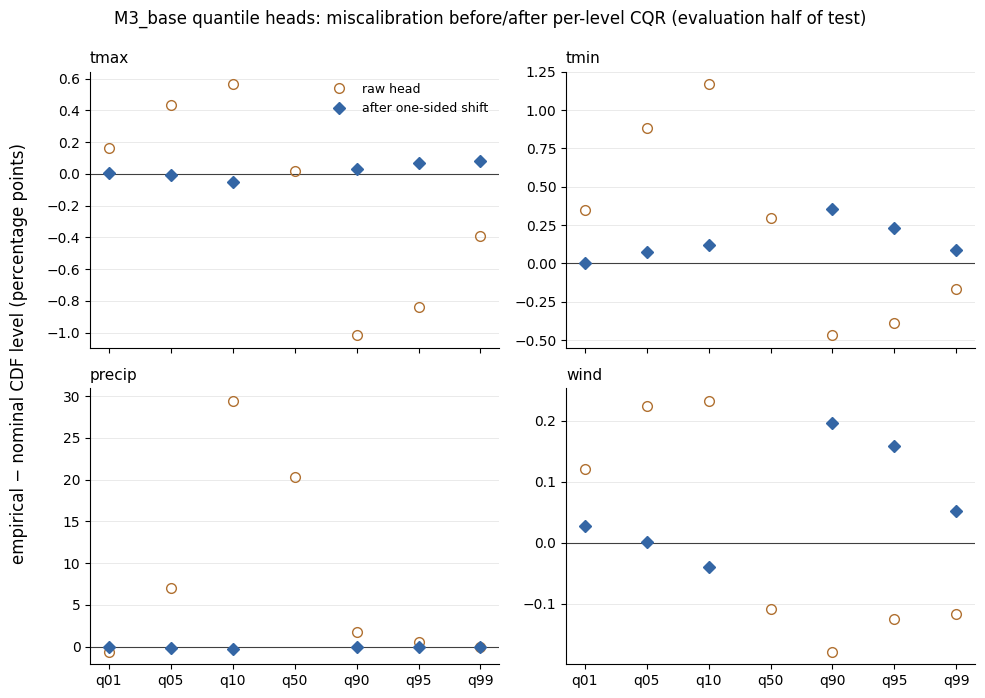

In [3]:
RAW_COLOR = "#B07030"         # uncorrected heads
CALIBRATED_COLOR = "#3466A5"  # after the one-sided shifts

# sharey=False: precip's raw dry-day atom (+30pp) must not squash the
# temperature panels onto the zero line
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
x_all = np.arange(len(QUANTILE_LEVELS))
x_labels = [f"q{int(level * 100):02d}" for level in QUANTILE_LEVELS]
for ax, name in zip(axes.flat, VAR_NAMES):
    per_var = coverage[coverage["var"] == name]
    raw_cdf = per_var[per_var.stage == "raw"].set_index("level").empirical_cdf
    cal_cdf = per_var[per_var.stage == "calibrated"].set_index("level").empirical_cdf
    ax.axhline(0, color="0.25", lw=0.8)
    ax.plot(x_all, [(raw_cdf[level] - level) * 100 for level in QUANTILE_LEVELS],
            "o", mfc="none", color=RAW_COLOR, ms=7, ls="", label="raw head")
    ax.plot([LEVEL_COLUMN[level] for level in SIDED_LEVELS],
            [(cal_cdf[level] - level) * 100 for level in SIDED_LEVELS],
            "D", color=CALIBRATED_COLOR, ms=6, ls="", label="after one-sided shift")
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_xticks(x_all, x_labels)
    ax.grid(axis="y", color="0.9", lw=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.supylabel("empirical − nominal CDF level (percentage points)")
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("M3_base quantile heads: miscalibration before/after per-level CQR"
             " (evaluation half of test)", y=0.99)
fig.tight_layout()
plt.show()


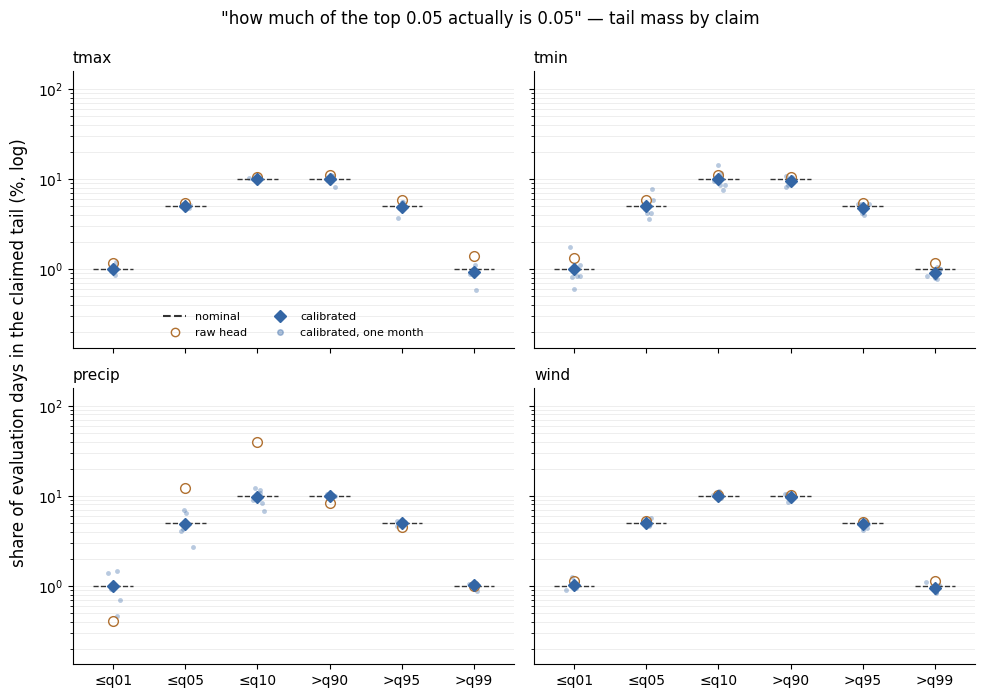

In [4]:
from matplotlib.lines import Line2D

CLAIMS = [(0.01, "≤q01"), (0.05, "≤q05"), (0.10, "≤q10"),
          (0.90, ">q90"), (0.95, ">q95"), (0.99, ">q99")]
nominal_pct = [level * 100 if level < 0.5 else (1 - level) * 100
               for level, _ in CLAIMS]

jitter_rng = np.random.default_rng(0)
zero_months = 0
plotted_pct = []          # every positive plotted value -> data-driven y-limits
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for ax, name in zip(axes.flat, VAR_NAMES):
    per_var = coverage[coverage["var"] == name].set_index(["stage", "level"]).empirical_cdf
    for i, (level, _) in enumerate(CLAIMS):
        months = monthly_tails[(monthly_tails["var"] == name)
                               & (monthly_tails.level == level)].tail_mass.to_numpy()
        zero_months += int((months == 0).sum())
        month_pct = np.where(months > 0, months, np.nan) * 100
        plotted_pct += [m for m in month_pct if np.isfinite(m)]
        ax.plot(i + jitter_rng.normal(0, 0.05, len(months)), month_pct,
                "o", color=CALIBRATED_COLOR, ms=3.5, alpha=0.35, mec="none")
        ax.hlines(nominal_pct[i], i - 0.28, i + 0.28, color="0.2", lw=1, ls="--")
        for stage, marker, color, fill in (("raw", "o", RAW_COLOR, "none"),
                                           ("calibrated", "D", CALIBRATED_COLOR, None)):
            cdf = per_var.loc[(stage, level)]
            tail = cdf if level < 0.5 else 1 - cdf
            if tail < 1e-9:           # float dust from 1 - cdf, or a truly empty tail
                continue
            plotted_pct.append(tail * 100)
            ax.plot(i, tail * 100, marker, ms=7 if stage == "raw" else 6,
                    color=color, mfc=fill)
    ax.set_yscale("log")
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_xticks(range(len(CLAIMS)), [claim for _, claim in CLAIMS])
    ax.grid(axis="y", color="0.92", lw=0.6, which="both")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0, 0].set_ylim(min(plotted_pct) / 3, max(plotted_pct) * 4)   # sharey spreads it
fig.supylabel("share of evaluation days in the claimed tail (%, log)")
axes[0, 0].legend(handles=[
    Line2D([], [], ls="--", color="0.2", label="nominal"),
    Line2D([], [], marker="o", mfc="none", color=RAW_COLOR, ls="", label="raw head"),
    Line2D([], [], marker="D", color=CALIBRATED_COLOR, ls="", label="calibrated"),
    Line2D([], [], marker="o", color=CALIBRATED_COLOR, ls="", ms=4, alpha=0.4,
           label="calibrated, one month")],
    frameon=False, fontsize=8, loc="lower center", ncol=2)
fig.suptitle('"how much of the top 0.05 actually is 0.05" — tail mass by claim',
             y=0.99)
fig.tight_layout()
plt.show()
if zero_months:
    print(f"note: {zero_months} (var, level, month) tail masses were exactly 0"
          " -> dropped from the log plot")


## Conditional coverage — does an extreme forecast stay calibrated?

The conformal guarantee above is **marginal**: averaged over all evaluation
days. But the product claims fire precisely on the non-average days — a
"hottest 1%" banner appears when the forecast itself is extreme. Nothing
guarantees the global shifts hold there; that's an empirical question, answered
here by slicing the same evaluation days by **forecast extremeness**:

- Each day's forecast is ranked within its own cell's *training* forecast
  distribution (~2 years of days), giving a within-cell percentile — so
  "extreme" means extreme for that place, not globally.
- Days are binned by that percentile; per bin × claim, the tail mass at the
  *same global calibrated heads* is measured. `conditional_ratio` shows
  empirical/nominal (1.00 = perfectly honest; 2 = the claim fires twice as
  often as advertised in that regime).
- The figure condenses to three regimes: bottom 5%, middle 50%, top 5% of
  forecasts. The money cells are the **top-5% regime × upper claims** — that's
  the exact population "this is one of the hottest days" is shown to.

If the extreme regimes drift badly, the remedy is already scored in part 10:
per-forecast-decile CQR (bin-conditional constants) instead of one global
shift per level. Precip note: the dry atom means no cell has forecasts below
its ~60th training percentile, so precip's lower bins are empty by
construction — judge precip in the top bins only.


bin           bottom 1%  1–5%  5–25%  25–75%  75–95%  95–99%  top 1%
var    level                                                        
tmax   0.01        1.56  2.15   0.93    0.98    0.85    1.05    1.20
       0.05        1.11  1.64   0.94    0.99    0.93    1.11    1.04
       0.10        1.07  1.37   0.95    0.99    0.95    1.06    1.02
       0.90        1.20  1.03   1.00    0.94    1.05    1.17    1.15
       0.95        1.32  1.10   0.97    0.90    1.07    1.29    1.14
       0.99        1.83  1.26   0.87    0.82    0.95    1.40    1.18
tmin   0.01        1.38  1.12   1.07    1.00    0.82    1.05    1.42
       0.05        0.89  0.93   1.07    1.02    0.97    0.98    1.12
       0.10        0.84  0.90   1.04    1.02    0.98    1.01    1.06
       0.90        1.50  1.18   1.00    0.88    1.00    1.06    1.12
       0.95        1.58  1.28   1.00    0.86    0.98    1.04    1.11
       0.99        1.94  1.43   0.94    0.80    0.92    0.98    1.47
precip 0.01         NaN  0.00   0.29    0.70    1.24    1.57    0.58
       0.05         NaN  0.34   0.49    0.60    1.22    1.39    2.04
       0.10         NaN  0.52   1.03    0.72    1.16    1.29    1.24
       0.90         NaN  2.93   1.14    1.00    1.02    0.97    0.94
       0.95         NaN  3.45   1.19    0.95    1.03    1.06    1.04
       0.99         NaN  8.62   1.31    0.97    1.09    0.98    0.50
wind   0.01        1.33  1.19   1.07    0.98    1.00    1.13    1.87
       0.05        0.84  1.03   1.04    0.98    0.98    1.02    1.47
       0.10        0.84  0.99   1.03    0.98    0.98    1.03    1.38
       0.90        1.29  1.07   0.93    0.98    0.99    0.99    0.87
       0.95        1.37  1.06   0.91    0.96    1.00    0.99    0.80
       0.99        1.47  1.25   0.82    0.92    1.05    0.88    0.85

smallest bin: n=0 — at the 1% claims a bin needs a few thousand rows before the ratio outruns binomial noise


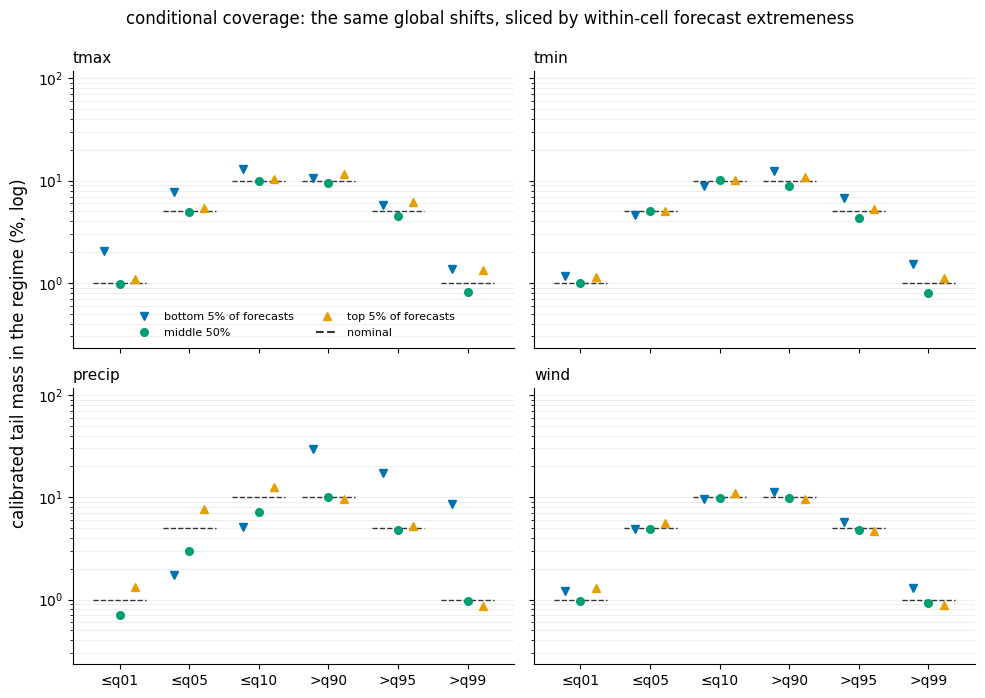

In [5]:
CLAIMS = [(0.01, "≤q01"), (0.05, "≤q05"), (0.10, "≤q10"),
          (0.90, ">q90"), (0.95, ">q95"), (0.99, ">q99")]
nominal_pct = [level * 100 if level < 0.5 else (1 - level) * 100
               for level, _ in CLAIMS]

# empirical/nominal ratio per fine bin (1.00 = honest), the full detail table
conditional["ratio"] = conditional.tail_mass / [
    level if level < 0.5 else round(1 - level, 6) for level in conditional.level]
conditional_ratio = (conditional.pivot_table(index=["var", "level"], columns="bin",
                                             values="ratio", observed=False)
                     .reindex(index=VAR_NAMES, level=0)
                     .reindex(columns=FORECAST_BIN_LABELS))
display(conditional_ratio.round(2))
print(f"smallest bin: n={conditional.n.min():,} — at the 1% claims a bin needs"
      " a few thousand rows before the ratio outruns binomial noise")

# condensed to three regimes; the money cells are top-5% x upper claims
REGIMES = [("bottom 5% of forecasts", ["bottom 1%", "1–5%"], "#0072B2", "v"),
           ("middle 50%", ["25–75%"], "#009E73", "o"),
           ("top 5% of forecasts", ["95–99%", "top 1%"], "#E69F00", "^")]

plotted_pct = []
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for ax, name in zip(axes.flat, VAR_NAMES):
    for i, (level, _) in enumerate(CLAIMS):
        ax.hlines(nominal_pct[i], i - 0.38, i + 0.38, color="0.2", lw=1, ls="--")
        for offset, (regime, bins, color, marker) in zip((-0.22, 0, 0.22), REGIMES):
            sub = conditional[(conditional["var"] == name)
                              & (conditional.level == level)
                              & conditional.bin.isin(bins)].dropna(subset=["tail_mass"])
            if not sub.n.sum():
                continue
            mass_pct = (sub.tail_mass * sub.n).sum() / sub.n.sum() * 100
            if mass_pct <= 0:
                continue
            plotted_pct.append(mass_pct)
            ax.plot(i + offset, mass_pct, marker, color=color, ms=5.5)
    ax.set_yscale("log")
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_xticks(range(len(CLAIMS)), [claim for _, claim in CLAIMS])
    ax.grid(axis="y", color="0.92", lw=0.6, which="both")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
axes[0, 0].set_ylim(min(plotted_pct) / 3, max(plotted_pct) * 4)
fig.supylabel("calibrated tail mass in the regime (%, log)")
from matplotlib.lines import Line2D
axes[0, 0].legend(handles=[
    Line2D([], [], marker=marker, color=color, ls="", ms=5.5, label=regime)
    for regime, _, color, marker in REGIMES]
    + [Line2D([], [], ls="--", color="0.2", label="nominal")],
    frameon=False, fontsize=8, loc="lower center", ncol=2)
fig.suptitle("conditional coverage: the same global shifts, sliced by"
             " within-cell forecast extremeness", y=0.99)
fig.tight_layout()
plt.show()


## Caveats / what to look for

- **Precip lower tails are near-meaningless**: the bias distribution has an
  atom where forecast and archive are both dry, so `≤q01/≤q05/≤q10` coverage is
  tie-dominated (we count `≤`, atoms can overshoot the nominal mass). The
  product claim for precip is the wet **upper** tail; judge precip there.
- **The monthly dots are the real story for the tails.** The aggregate
  calibrated marker sits on nominal by construction (that's the conformal
  guarantee, marginal over everything); the spread of the per-month dots is the
  conditional miscoverage a single global shift cannot fix — expect it wider at
  q99 than at q90. Wide dots at the extreme levels ⇒ use fuzzy wording bins
  ("virtually certain", "likely") on those rungs, not precise probabilities.
- If this looks good, the bake change in `make_debias_tables.py` is: ship all 7
  delta columns (not `dlo/dmid/dhi`), add each level's shift, **re-sort per
  row**, and the client interpolates the 7-point CDF — clamping beyond
  q01/q99 to "<1%"/">99%".
- Shifts land in `models/per_level_cqr_qn8727_s0.csv` (full runs only).
